# BNS Dataset Inspection
Randomly select one event from the generated dataset, visualise the time series / PSD / FFT, and verify the data are consistent with the generation config.

In [22]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import yaml, os, random
from gwpy.timeseries import TimeSeries

H5_DIR     = "/n/holystore01/LABS/iaifi_lab/Lab/kyoon/DATA/lite/BNS_SNR50_umass_nospin/test"
CONFIG_PATH = "/n/holystore01/LABS/iaifi_lab/Lab/kyoon/GWDatasetGeneration/configs/lite/BNS_SNR50_umass_nospin.yaml"

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

sample_rate     = cfg['general']['sample_rate']          # Hz (native)
downsample_rate = cfg['general'].get('downsample_rate', 1)
effective_rate  = sample_rate // downsample_rate          # Hz after downsampling

kernel_length = cfg['general']['waveform_duration']       # 64 s
fduration     = cfg['whiten']['fduration']                # 2 s
psd_length    = cfg['whiten']['psd_length']               # 64 s

# Expected sample counts
raw_samples      = int((kernel_length + fduration) * effective_rate)  # 270336
whitened_samples = int(kernel_length * effective_rate)                  # 262144

print(f"Config sample_rate   : {sample_rate} Hz")
print(f"Downsample rate      : {downsample_rate}")
print(f"Effective rate       : {effective_rate} Hz")
print(f"Expected raw samples : {raw_samples}  ({raw_samples/effective_rate:.1f} s)")
print(f"Expected wht samples : {whitened_samples}  ({whitened_samples/effective_rate:.1f} s)")

Config sample_rate   : 4096 Hz
Downsample rate      : 1
Effective rate       : 4096 Hz
Expected raw samples : 270336  (66.0 s)
Expected wht samples : 262144  (64.0 s)


In [23]:
# ── Load a random event ───────────────────────────────────────────────────────
random.seed()   # fresh seed every run

files = sorted(f for f in os.listdir(H5_DIR) if f.endswith('.h5'))
chosen_file = random.choice(files)
print(f"File : {chosen_file}")

SCALAR_KEYS = ['chi1','chi2','chirp_mass','dec','distance','inclination',
               'mass_1','mass_2','mass_ratio','phi','phic','psi','s1z','s2z','snr']

with h5py.File(os.path.join(H5_DIR, chosen_file), 'r') as f:
    n_events = f['whitened_injected'].shape[0]
    idx = random.randint(0, n_events - 1)
    print(f"Event: {idx} / {n_events - 1}")

    whitened_injected = f['whitened_injected'][idx]   # (2, T_wht)
    whitened_signal   = f['whitened_signal'][idx]
    whitened_bkg      = f['whitened_bkg'][idx]
    raw_signal        = f['raw_signal'][idx]          # (2, T_raw)
    raw_bkg           = f['raw_bkg'][idx]

    params = {}
    for k in SCALAR_KEYS:
        v = f[k][()]
        params[k] = float(v[idx]) if v.ndim > 0 else float(v)

print("\nEvent parameters:")
for k, v in params.items():
    print(f"  {k:15s}: {v:.4f}")

File : sig_0.h5
Event: 85 / 99

Event parameters:
  chi1           : 0.0000
  chi2           : 0.0000
  chirp_mass     : 1.2076
  dec            : -0.5981
  distance       : 387.1695
  inclination    : 2.0418
  mass_1         : 1.2645
  mass_2         : 1.5243
  mass_ratio     : 1.2055
  phi            : 1.9637
  phic           : 0.0000
  psi            : 0.3711
  s1z            : 0.0000
  s2z            : 0.0000
  snr            : 50.0000


## Time series
Whitened injected (signal + background), whitened signal only, and whitened background.  
H1 (Hanford) in blue, L1 (Livingston) in orange — matching LIGO paper convention.

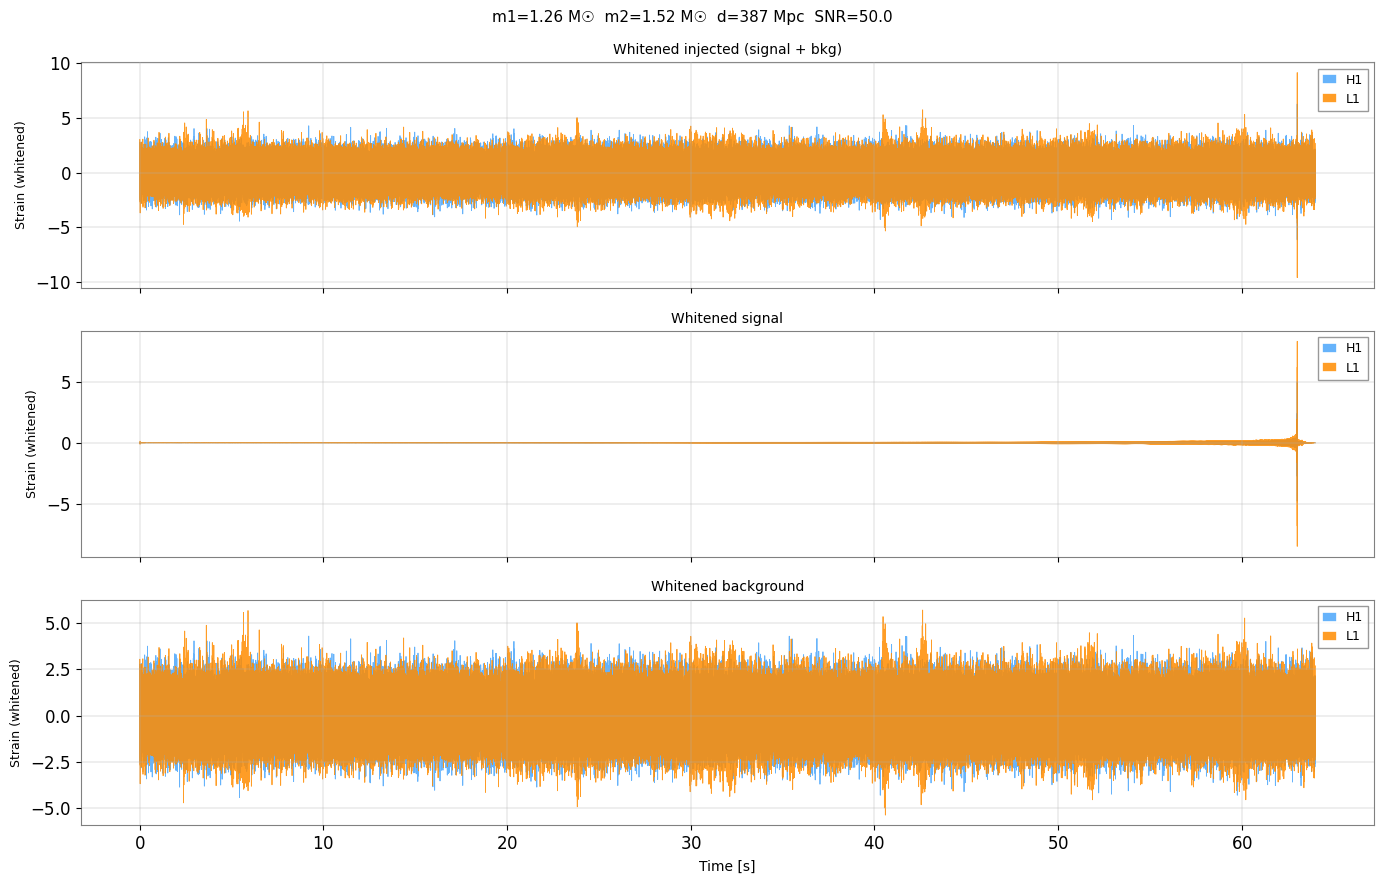

In [24]:
IFO_COLORS = {'H1': '#4ba6fb', 'L1': '#ff8c00'}   # blue / orange
IFO_NAMES  = cfg['general']['ifos']                 # ['H1', 'L1']

def make_ts(data_1d, fs):
    """Wrap a 1-D numpy array as a gwpy TimeSeries starting at t=0."""
    return TimeSeries(data_1d.astype(float), sample_rate=fs, t0=0)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
titles = ['Whitened injected (signal + bkg)', 'Whitened signal', 'Whitened background']
datasets = [whitened_injected, whitened_signal, whitened_bkg]

for ax, data, title in zip(axes, datasets, titles):
    for ch_idx, ifo in enumerate(IFO_NAMES):
        ts = make_ts(data[ch_idx], effective_rate)
        ax.plot(ts.times.value, ts.value,
                color=IFO_COLORS[ifo], lw=0.6, alpha=0.85, label=ifo)
    ax.set_ylabel('Strain (whitened)', fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, lw=0.3)

axes[-1].set_xlabel('Time [s]', fontsize=10)
fig.suptitle(
    f"m1={params['mass_1']:.2f} M☉  m2={params['mass_2']:.2f} M☉  "
    f"d={params['distance']:.0f} Mpc  SNR={params['snr']:.1f}",
    fontsize=11
)
plt.tight_layout()
plt.show()

## Power Spectral Density (PSD)
PSD of the **raw** (unwhitened) signal and background.  
The raw arrays include the `fduration=2 s` buffer, giving `kernel_length + fduration = 66 s` per sample.

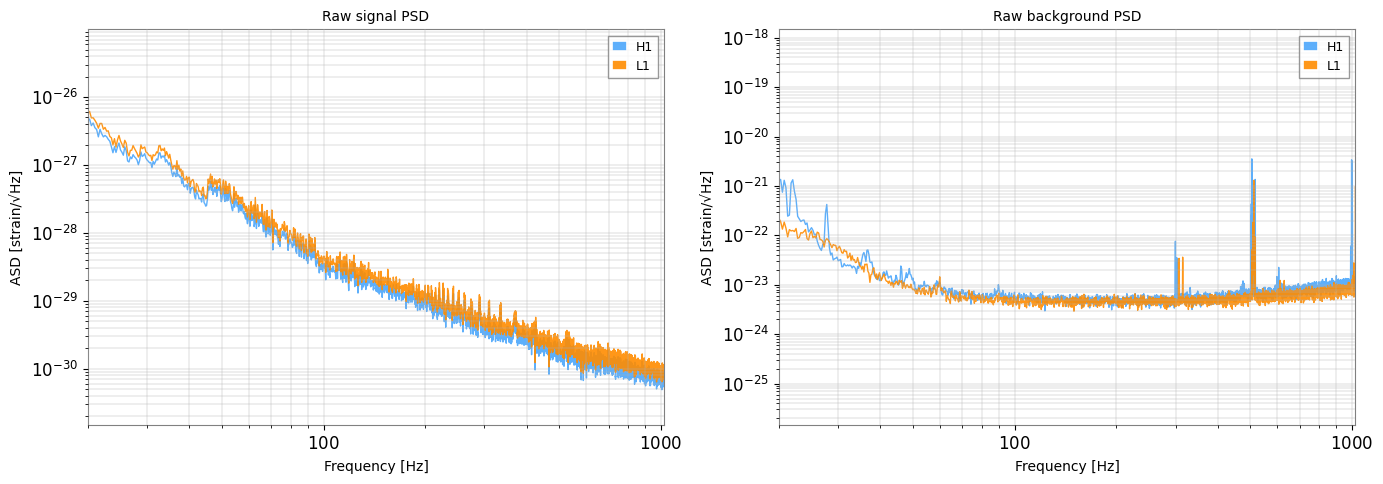

In [25]:
fft_length = 4   # seconds — controls frequency resolution (df = 1/fftlength = 0.25 Hz)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
titles_psd = ['Raw signal PSD', 'Raw background PSD']
raw_datasets = [raw_signal, raw_bkg]

for ax, data, title in zip(axes, raw_datasets, titles_psd):
    for ch_idx, ifo in enumerate(IFO_NAMES):
        ts  = make_ts(data[ch_idx], effective_rate)
        psd = ts.psd(fftlength=fft_length, overlap=fft_length//2, method='median')
        asd = psd ** 0.5   # Amplitude Spectral Density: easier to read on log scale
        ax.loglog(asd.frequencies.value, asd.value,
                  color=IFO_COLORS[ifo], lw=1.0, alpha=0.9, label=ifo)

    ax.set_xlabel('Frequency [Hz]', fontsize=10)
    ax.set_ylabel('ASD [strain/√Hz]', fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.set_xlim(cfg['general']['f_min'], cfg['general']['f_max'])
    ax.legend(fontsize=9)
    ax.grid(True, which='both', lw=0.3)

plt.tight_layout()
plt.show()

## Whitened background PSD
After whitening the background should be approximately flat (white noise) with unit variance per frequency bin. Significant deviations indicate lines or non-stationarity.

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))

for ch_idx, ifo in enumerate(IFO_NAMES):
    ts  = make_ts(whitened_bkg[ch_idx], effective_rate)
    psd = ts.psd(fftlength=fft_length, overlap=fft_length//2, method='median')
    ax.semilogy(psd.frequencies.value, psd.value,
                color=IFO_COLORS[ifo], lw=1.0, alpha=0.9, label=ifo)

ax.axhline(1.0, color='k', lw=1.0, ls='--', label='expected (white noise = 1)')
ax.set_xlabel('Frequency [Hz]', fontsize=10)
ax.set_ylabel('PSD [(whitened strain)²/Hz]', fontsize=10)
ax.set_title('Whitened background PSD', fontsize=10)
ax.set_xlim(cfg['general']['f_min'], cfg['general']['f_max'])
ax.legend(fontsize=9)
ax.grid(True, which='both', lw=0.3)
plt.tight_layout()
plt.show()

## FFT vs PSD — what is the difference?

| | **FFT** | **PSD** |
|---|---|---|
| **Output** | Complex amplitudes at each frequency bin | Real-valued power per unit frequency |
| **Units** | [signal units] (e.g. strain) | [signal units]² / Hz (e.g. strain²/Hz) |
| **Normalisation** | Not normalised — scales with segment length *N* | Normalised by *N* and sampling rate so that ∫PSD df = variance of the signal |
| **Averaging** | Single periodogram (noisy) | Welch's method: average many overlapping short FFTs → much smoother |
| **Use case** | Inspect spectral content of a *specific* finite segment | Characterise the *stationary* noise floor of a detector |

**In short**: the FFT of a single segment is a noisy snapshot; the PSD averages many such snapshots so the detector noise curve is visible.  
The **ASD** (Amplitude Spectral Density = √PSD, units strain/√Hz) is what is usually plotted for LIGO sensitivity curves because it is directly comparable to GW strain amplitudes.

## FFT of raw signal and raw background
Single-segment periodogram (|FFT|) — notice how much noisier it is than the Welch PSD above.

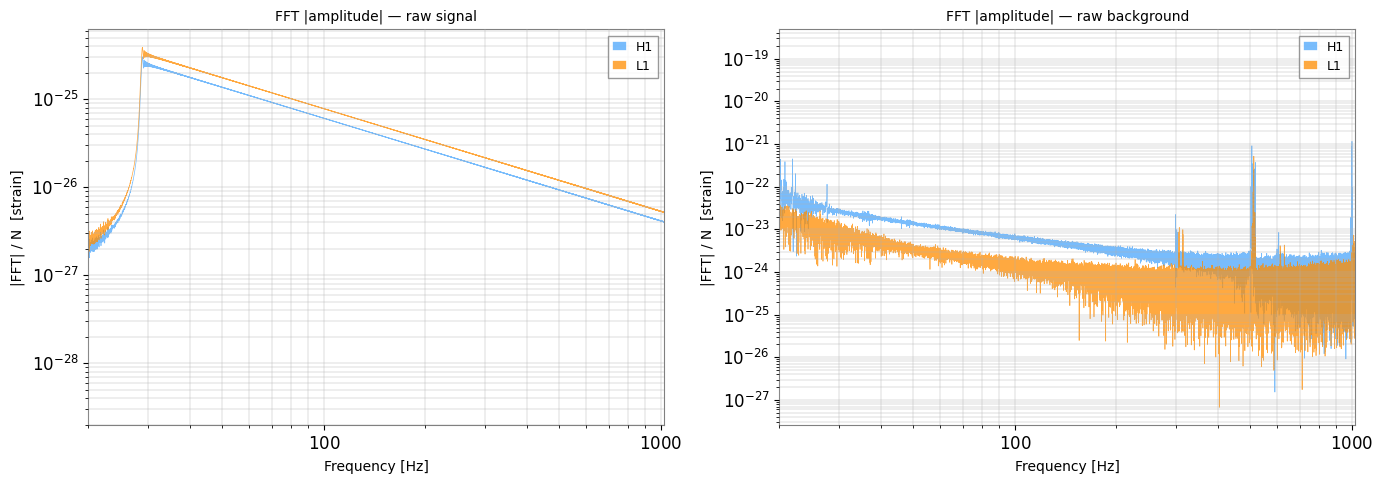

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
titles_fft = ['FFT |amplitude| — raw signal', 'FFT |amplitude| — raw background']
raw_datasets = [raw_signal, raw_bkg]

for ax, data, title in zip(axes, raw_datasets, titles_fft):
    for ch_idx, ifo in enumerate(IFO_NAMES):
        n = data[ch_idx].shape[0]
        freqs = np.fft.rfftfreq(n, d=1.0 / effective_rate)
        amp   = np.abs(np.fft.rfft(data[ch_idx].astype(float))) / n  # normalise by N
        ax.loglog(freqs, amp,
                  color=IFO_COLORS[ifo], lw=0.5, alpha=0.75, label=ifo)

    ax.set_xlabel('Frequency [Hz]', fontsize=10)
    ax.set_ylabel('|FFT| / N  [strain]', fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.set_xlim(cfg['general']['f_min'], cfg['general']['f_max'])
    ax.legend(fontsize=9)
    ax.grid(True, which='both', lw=0.3)

plt.tight_layout()
plt.show()

## Consistency checks
Verify the saved arrays match what the config prescribes.

In [27]:
def check(label, value, expected, tol=None, lo=None, hi=None):
    if tol is not None:
        ok = abs(value - expected) <= tol
        status = "✓" if ok else "✗"
        print(f"  {status}  {label}: {value}  (expected {expected} ± {tol})")
    elif lo is not None:
        ok = lo <= value <= hi
        status = "✓" if ok else "✗"
        print(f"  {status}  {label}: {value:.4f}  (expected in [{lo}, {hi}])")
    return ok

print("─── Array shapes ───────────────────────────────────────────────")
ok1 = check("raw_signal  samples", raw_signal.shape[-1],   raw_samples,      tol=0)
ok2 = check("raw_bkg     samples", raw_bkg.shape[-1],      raw_samples,      tol=0)
ok3 = check("wht_signal  samples", whitened_signal.shape[-1], whitened_samples, tol=0)
ok4 = check("wht_bkg     samples", whitened_bkg.shape[-1],    whitened_samples, tol=0)
ok5 = check("n_channels",          raw_signal.shape[0],    len(IFO_NAMES),   tol=0)

print("\n─── Inferred sample rate ────────────────────────────────────────")
inferred_raw = raw_signal.shape[-1] / (kernel_length + fduration)
inferred_wht = whitened_signal.shape[-1] / kernel_length
ok6 = check("raw  effective_rate [Hz]", inferred_raw, effective_rate, tol=0)
ok7 = check("wht  effective_rate [Hz]", inferred_wht, effective_rate, tol=0)

print("\n─── Physical parameters (this event) ───────────────────────────")
m1_lo, m1_hi = cfg['waveform']['mass_1']['args']
m2_lo, m2_hi = cfg['waveform']['mass_2']['args']
d_lo,  d_hi  = cfg['waveform']['distance']['args'][:2]
target_snr   = cfg['snr_reweighting']['args'][0]

ok8  = check("mass_1   [M☉]",   params['mass_1'],   None,       lo=m1_lo,     hi=m1_hi)
ok9  = check("mass_2   [M☉]",   params['mass_2'],   None,       lo=m2_lo,     hi=m2_hi)
ok10 = check("distance [Mpc]",   params['distance'], None,       lo=d_lo,      hi=d_hi)
ok11 = check("SNR",              params['snr'],      target_snr, tol=0.5)
ok12 = check("s1z (no-spin)",    params['s1z'],      0.0,        tol=1e-5)
ok13 = check("s2z (no-spin)",    params['s2z'],      0.0,        tol=1e-5)

all_ok = all([ok1,ok2,ok3,ok4,ok5,ok6,ok7,ok8,ok9,ok10,ok11,ok12,ok13])
print(f"\n{'All checks passed ✓' if all_ok else 'Some checks FAILED ✗'}")

─── Array shapes ───────────────────────────────────────────────
  ✓  raw_signal  samples: 270336  (expected 270336 ± 0)
  ✓  raw_bkg     samples: 270336  (expected 270336 ± 0)
  ✓  wht_signal  samples: 262144  (expected 262144 ± 0)
  ✓  wht_bkg     samples: 262144  (expected 262144 ± 0)
  ✓  n_channels: 2  (expected 2 ± 0)

─── Inferred sample rate ────────────────────────────────────────
  ✓  raw  effective_rate [Hz]: 4096.0  (expected 4096 ± 0)
  ✓  wht  effective_rate [Hz]: 4096.0  (expected 4096 ± 0)

─── Physical parameters (this event) ───────────────────────────
  ✓  mass_1   [M☉]: 1.2645  (expected in [1.0, 2.5])
  ✓  mass_2   [M☉]: 1.5243  (expected in [1.0, 2.5])
  ✓  distance [Mpc]: 387.1695  (expected in [100, 1000])
  ✓  SNR: 50.000003814697266  (expected 50 ± 0.5)
  ✓  s1z (no-spin): 0.0  (expected 0.0 ± 1e-05)
  ✓  s2z (no-spin): 0.0  (expected 0.0 ± 1e-05)

All checks passed ✓


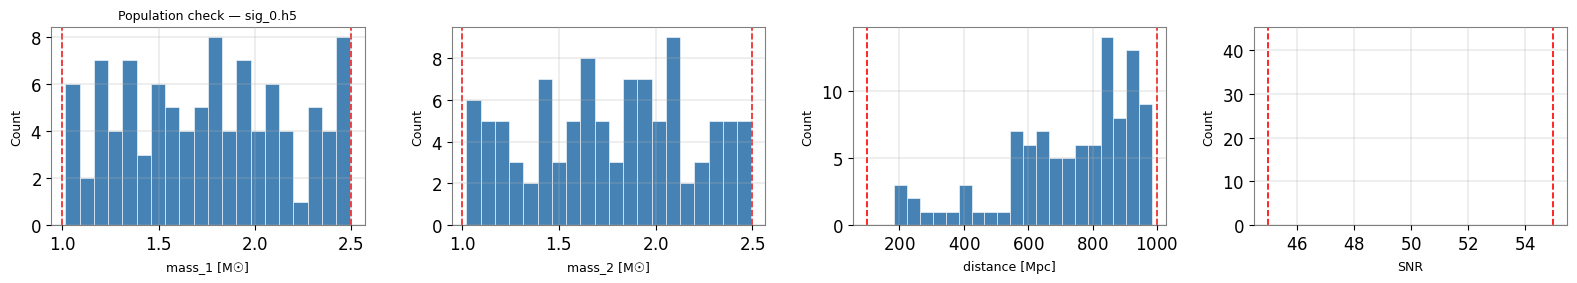

In [28]:
# ── Population distributions (all events in the file) ─────────────────────
with h5py.File(os.path.join(H5_DIR, chosen_file), 'r') as f:
    all_m1  = f['mass_1'][()]
    all_m2  = f['mass_2'][()]
    all_d   = f['distance'][()]
    all_snr = f['snr'][()]

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
bins = 20
for ax, data, label, lo, hi in zip(
        axes,
        [all_m1, all_m2, all_d, all_snr],
        ['mass_1 [M☉]', 'mass_2 [M☉]', 'distance [Mpc]', 'SNR'],
        [m1_lo, m2_lo, d_lo, target_snr - 5],
        [m1_hi, m2_hi, d_hi, target_snr + 5]):
    ax.hist(data, bins=bins, color='steelblue', edgecolor='white', lw=0.4)
    ax.axvline(lo, color='red',  lw=1.2, ls='--', label='config min/target')
    ax.axvline(hi, color='red',  lw=1.2, ls='--')
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.grid(True, lw=0.3)

axes[0].set_title(f'Population check — {chosen_file}', fontsize=9)
plt.tight_layout()
plt.show()